In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Objective:
- Analyze distributional differences across train/validation/test splits
- Detect potential pre-training data drift
- Study dialogue and summary characteristics before model training

In [3]:
!pip install -r /content/drive/MyDrive/ml_projects/NLP_Text_Summarization/requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.0 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=043531a78410f0fd5a0ad6691afb734e6f887e668f9ec218f4774f2882347ece
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset


In [7]:
RAW_DATA_DIR = Path("/content/drive/MyDrive/ml_projects/NLP_Text_Summarization/artifacts/data/raw")

data_files = {
    "train": str(RAW_DATA_DIR / "samsum_train.json"),
    "validation": str(RAW_DATA_DIR / "samsum_validation.json"),
    "test": str(RAW_DATA_DIR / "samsum_test.json"),
}
dataset = load_dataset("json", data_files=data_files)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [8]:
for split in dataset:
    print(f"{split}: {len(dataset[split])}")


train: 14731
validation: 818
test: 819


In [9]:
def compute_lengths(texts):
    return [len(t.split()) for t in texts]

lengths = {}
for split in dataset:
    lengths[split] = compute_lengths(dataset[split]["dialogue"])

In [10]:
summary_lengths = {}
for split in dataset:
    summary_lengths[split] = compute_lengths(dataset[split]["summary"])

In [11]:
stats = []

for split in dataset:
    stats.append({
        "split": split,
        "dialogue_mean": np.mean(lengths[split]),
        "dialogue_median": np.median(lengths[split]),
        "dialogue_p95": np.percentile(lengths[split], 95),
        "summary_mean": np.mean(summary_lengths[split]),
        "summary_median": np.median(summary_lengths[split]),
        "summary_p95": np.percentile(summary_lengths[split], 95),
    })
pd.DataFrame(stats)


,split,dialogue_mean,dialogue_median,dialogue_p95,summary_mean,summary_median,summary_p95
0,train,93.792750,73.0,237.00,20.318444,18.0,43.0
1,validation,91.641809,70.0,225.75,20.283619,18.0,43.0
2,test,95.507937,74.0,252.30,20.017094,18.0,41.0


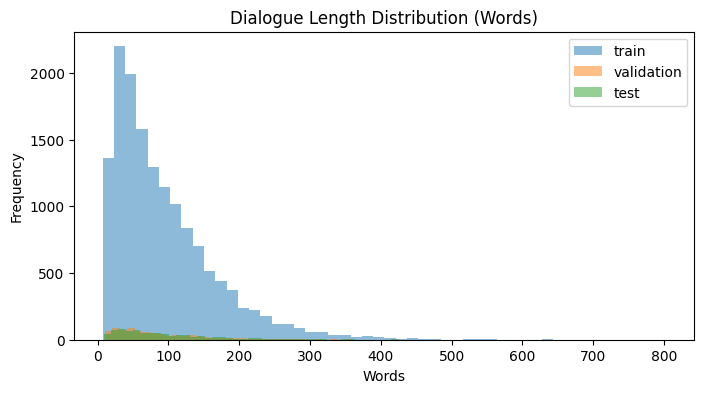

In [12]:
plt.figure(figsize=(8, 4))

for split in dataset:
    plt.hist(
        lengths[split],
        bins=50,
        alpha=0.5,
        label=split
    )
plt.legend()
plt.title("Dialogue Length Distribution (Words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


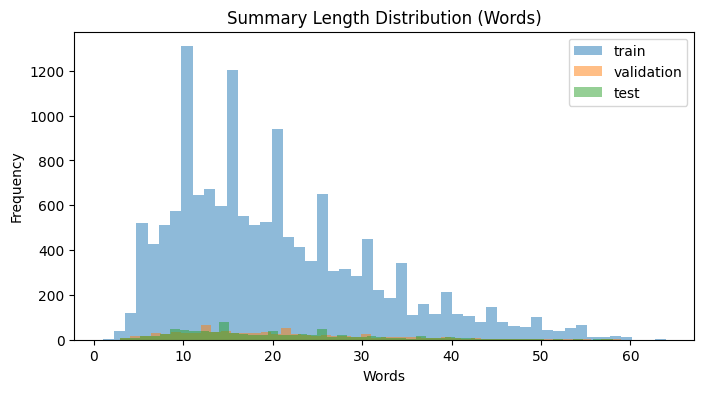

In [13]:
plt.figure(figsize=(8, 4))

for split in dataset:
    plt.hist(
        summary_lengths[split],
        bins=50,
        alpha=0.5,
        label=split
    )

plt.legend()
plt.title("Summary Length Distribution (Words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [14]:
def vocab_set(texts):
    vocab = set()
    for t in texts:
        vocab.update(t.lower().split())
    return vocab

vocabs = {
    split: vocab_set(dataset[split]["dialogue"])
    for split in dataset
}

for split in ["validation", "test"]:
    overlap = len(vocabs["train"].intersection(vocabs[split]))
    union = len(vocabs["train"].union(vocabs[split]))
    jaccard = overlap / union
    print(f"Train vs {split} Jaccard similarity: {jaccard:.3f}")


Train vs validation Jaccard similarity: 0.134
Train vs test Jaccard similarity: 0.137


In [15]:
def speaker_count(dialogue):
    return len([x for x in dialogue.split("\n") if ":" in x])

speaker_stats = {}

for split in dataset:
    speaker_stats[split] = [
        speaker_count(d) for d in dataset[split]["dialogue"]
    ]

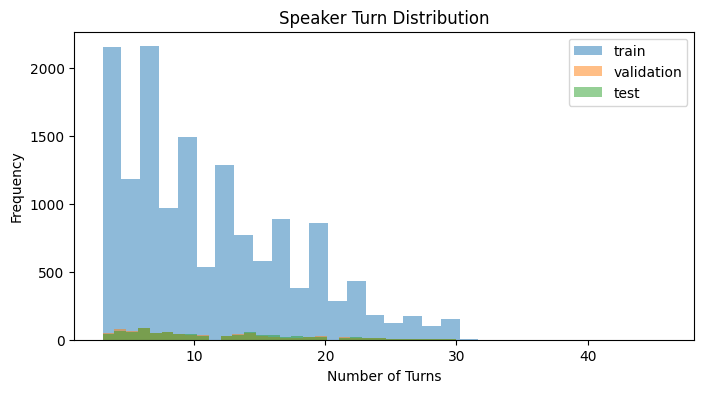

In [16]:
plt.figure(figsize=(8, 4))

for split in dataset:
    plt.hist(
        speaker_stats[split],
        bins=30,
        alpha=0.5,
        label=split
    )

plt.legend()
plt.title("Speaker Turn Distribution")
plt.xlabel("Number of Turns")
plt.ylabel("Frequency")
plt.show()
